# Projection of an ellipsoid
Reference to: https://ui.adsabs.harvard.edu/abs/1980A%26A....82..289B/abstract

An interactive illustration can be found at: https://www.desmos.com/3d/0c7idk6zni

Given an ellipsoid with semi-major axese $(a,b,c)$ where $a\geq b \gg c$. Alone a line of sight at the viewing angle $(\varphi, \theta)$, the apparent axis ratio after the plane-parallel projection is 
$$Q=\left\{ \frac{j+\ell-\sqrt{(j-\ell)^2+4k^2}}{j+\ell+\sqrt{(j-\ell)^2+4k^2}} \right\}^{1/2}$$
where
$$
\begin{aligned}
j &= q^2\sin^2\theta + p^2\sin^2\varphi\cos^2\theta + \cos^2\varphi\cos^2\theta \\
\ell &= p^2\cos^2\varphi + \sin^2\varphi \\
k &= (1-p^2)\sin\varphi\cos\varphi\cos\theta
\end{aligned}
$$
with $p=b/a$ and $q=c/a$. 

The ellipticity of the projection is
$$e=\frac{1-Q^2}{1+Q^2}$$

Consider $\varphi\in(0, \pi/2)$ and $\theta\in(-\pi/2, \pi/2)$

## Projected ellipticity

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [80]:
def axis_ratio(phi, theta, p, q):
    j = q**2 * np.sin(theta)**2 \
        + p**2 * np.sin(phi)**2 * np.cos(theta)**2 \
        + np.cos(phi)**2 * np.cos(theta)**2
    l = p**2 * np.cos(phi)**2 + np.sin(phi)**2
    k = (1 - p**2) * np.sin(phi) * np.cos(phi) * np.cos(theta)
    quadratic = np.sqrt((j-l)**2 + 4*k**2)
    return np.sqrt((j+l-quadratic) / (j+l + quadratic))

def ellipticity(phi, theta, p, q):
    Q = axis_ratio(phi, theta, p, q)
    return (1-Q**2) / (1+Q**2)

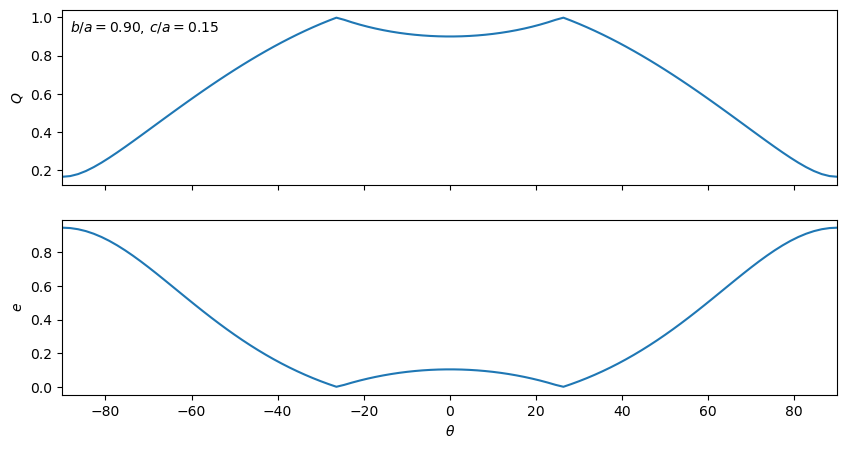

In [81]:
p = 0.9
q = 0.15

phi = 0.
theta = np.linspace(-np.pi/2, np.pi/2, 100)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

qz = axis_ratio(phi, theta, p, q)
axes[0].plot(theta*180/np.pi, qz)

e = ellipticity(phi, theta, p, q)
axes[1].plot(theta*180/np.pi, e)

axes[0].text(0.01, 0.95, r"$b/a=%.2f,\, c/a=%.2f$"%(p,q), transform=axes[0].transAxes, ha='left', va='top')
axes[0].set_ylabel(r"$Q$")
axes[1].set_ylabel(r"$e$")
axes[1].set_xlabel(r"$\theta$")
axes[1].set_xlim(-90., 90)

plt.show()

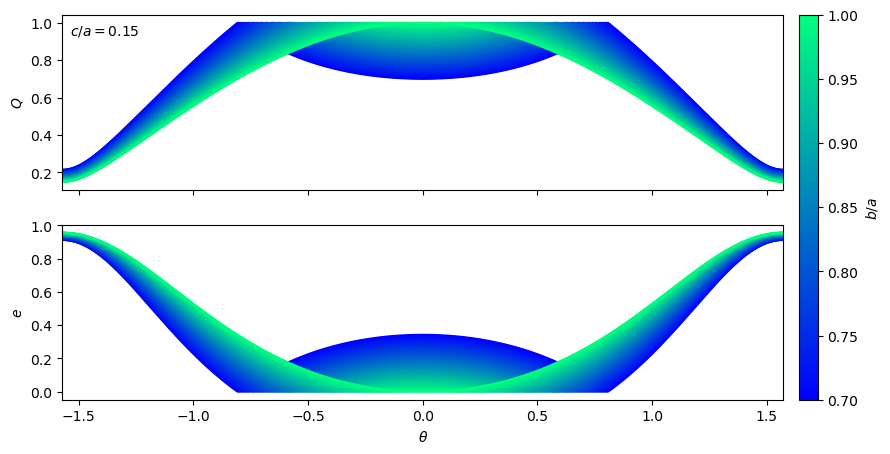

In [ ]:
p = 1.
q = 0.15

phi = 0.
theta = np.linspace(-np.pi/2, np.pi/2, 500)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

p_list = np.linspace(0.7, 1.0, 100)
cmap = plt.cm.winter
for i, p in enumerate(p_list):
    qz = axis_ratio(phi, theta, p, q)
    axes[0].plot(theta, qz, color=cmap(i/len(p_list)))

    e = ellipticity(phi, theta, p, q)
    axes[1].plot(theta, e, color=cmap(i/len(p_list)))

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=p_list[0], vmax=p_list[-1]))
cbar = fig.colorbar(sm, ax=axes, location='right', fraction=0.05, pad=0.02)
cbar.set_label(r"$b/a$")
axes[0].text(0.01, 0.95, r"$c/a=%.2f$"%q, transform=axes[0].transAxes, ha='left', va='top')
axes[0].set_ylabel(r"$Q$")
axes[1].set_ylabel(r"$e$")
axes[1].set_xlabel(r"$\theta$")
axes[1].set_xlim(-np.pi/2, np.pi/2)

plt.show()

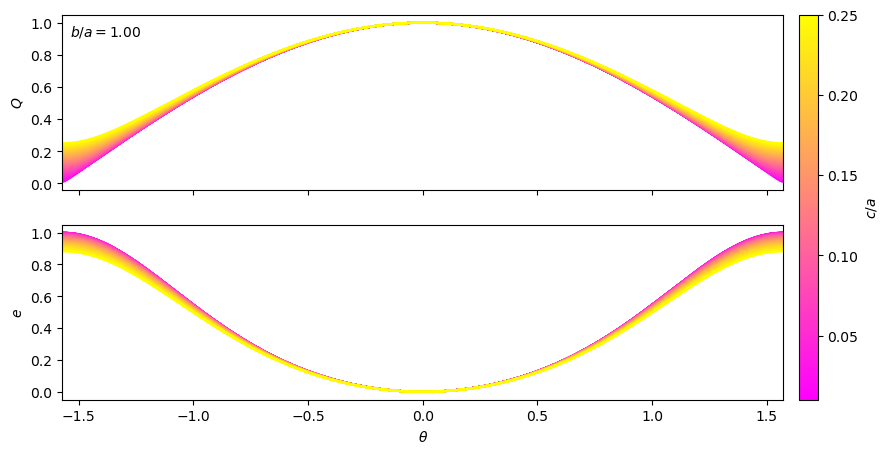

In [66]:
p = 1.00
q = 0.01

phi = 0.
theta = np.linspace(-np.pi/2, np.pi/2, 500)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

q_list = np.linspace(0.01, 0.25, 100)
cmap = plt.cm.spring
for i, q in enumerate(q_list):
    qz = axis_ratio(phi, theta, p, q)
    axes[0].plot(theta, qz, color=cmap(i/len(q_list)))

    e = ellipticity(phi, theta, p, q)
    axes[1].plot(theta, e, color=cmap(i/len(q_list)))

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=q_list[0], vmax=q_list[-1]))
cbar = fig.colorbar(sm, ax=axes, location='right', fraction=0.05, pad=0.02)
cbar.set_label(r"$c/a$")

axes[0].text(0.01, 0.95, r"$b/a=%.2f$"%p, transform=axes[0].transAxes, ha='left', va='top')
axes[0].set_ylabel(r"$Q$")
axes[1].set_ylabel(r"$e$")
axes[1].set_xlabel(r"$\theta$")
axes[1].set_xlim(-np.pi/2, np.pi/2)

plt.show()

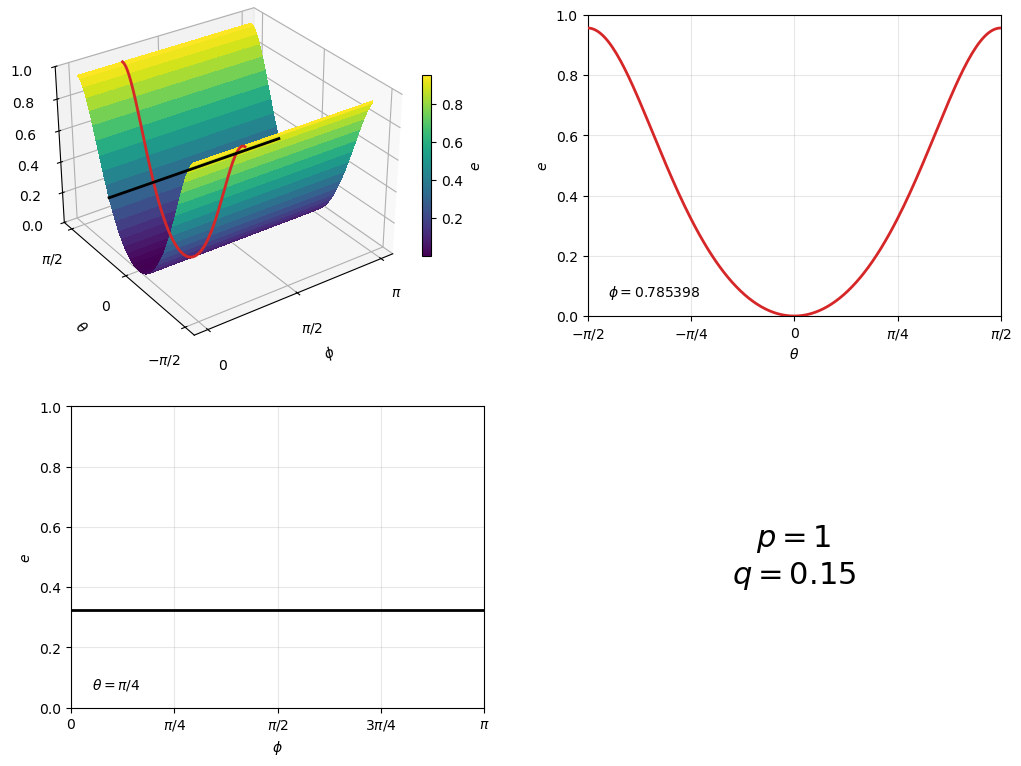

In [76]:
p = 1.0
q = 0.15
PHI0 = np.pi/4
THETA0 = np.pi/4
C_PHI, C_TH = "tab:red", "k"
EMAX = 1.0

n = 201
phi = np.linspace(0, np.pi, n)
theta = np.linspace(-np.pi/2, np.pi/2, n)
PHI, THETA = np.meshgrid(phi, theta)

E = ellipticity(PHI, THETA, p, q)
E_phi0 = ellipticity(PHI0, theta, p, q)
E_th0 = ellipticity(phi, THETA0, p, q)

fig = plt.figure(figsize=(12, 9))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)

# 3D
ax3d = fig.add_subplot(gs[0, 0], projection="3d")
ax3d.computed_zorder = False   # honour zorder instead of depth-sorting artists
ax3d.set_box_aspect(None, zoom=1.25)
surf = ax3d.plot_surface(PHI, THETA, E, cmap="viridis",
                         linewidth=0, antialiased=False, zorder=1)
ax3d.plot(np.full_like(theta, PHI0), theta, E_phi0, color=C_PHI, lw=2, zorder=10)
ax3d.plot(phi, np.full_like(phi, THETA0), E_th0, color=C_TH, lw=2, zorder=10)
ax3d.set_xlabel(r"$\phi$")
ax3d.set_ylabel(r"$\theta$")
ax3d.set_zlabel(r"$e$")
ax3d.set_xticks([0, np.pi / 2, np.pi])
ax3d.set_xticklabels(["0", r"$\pi/2$", r"$\pi$"])
ax3d.set_yticks([-np.pi / 2, 0, np.pi / 2])
ax3d.set_yticklabels([r"$-\pi/2$", "0", r"$\pi/2$"])
ax3d.set_zlim(0, EMAX)
ax3d.view_init(elev=30, azim=-125)
fig.colorbar(surf, ax=ax3d, shrink=0.6, pad=0.12, label=r"$e$")

# upper right: ellipticity vs theta at fixed phi
ax_r = fig.add_subplot(gs[0, 1])
ax_r.plot(theta, E_phi0, color=C_PHI, lw=2, zorder=10)
ax_r.set_xlabel(r"$\theta$")
ax_r.set_ylabel(r"$e$")
ax_r.text(0.05, 0.05, rf"$\phi = {PHI0:g}$", transform=ax_r.transAxes, va='bottom', ha='left')
ax_r.set_xlim(-np.pi / 2, np.pi / 2)
ax_r.set_xticks([-np.pi / 2, -np.pi / 4, 0, np.pi / 4, np.pi / 2])
ax_r.set_xticklabels([r"$-\pi/2$", r"$-\pi/4$", "0", r"$\pi/4$", r"$\pi/2$"])
ax_r.set_ylim(0, EMAX)
ax_r.grid(alpha=0.3)
 
# lower left: ellipticity vs phi at fixed theta
ax_l = fig.add_subplot(gs[1, 0])
ax_l.plot(phi, E_th0, color=C_TH, lw=2)
ax_l.set_xlabel(r"$\phi$")
ax_l.set_ylabel(r"$e$")
ax_l.text(0.05, 0.05, r"$\theta = \pi/4$", transform=ax_l.transAxes, va='bottom', ha='left')
ax_l.set_xlim(0, np.pi)
ax_l.set_xticks([0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
ax_l.set_xticklabels(["0", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"])
ax_l.set_ylim(0, EMAX)
ax_l.grid(alpha=0.3)

ax_info = fig.add_subplot(gs[1, 1])
ax_info.axis("off")
ax_info.text(0.5, 0.5, f"$p = {p:g}$\n$q = {q:g}$", ha="center", va="center",
        fontsize=22, transform=ax_info.transAxes)
plt.show()

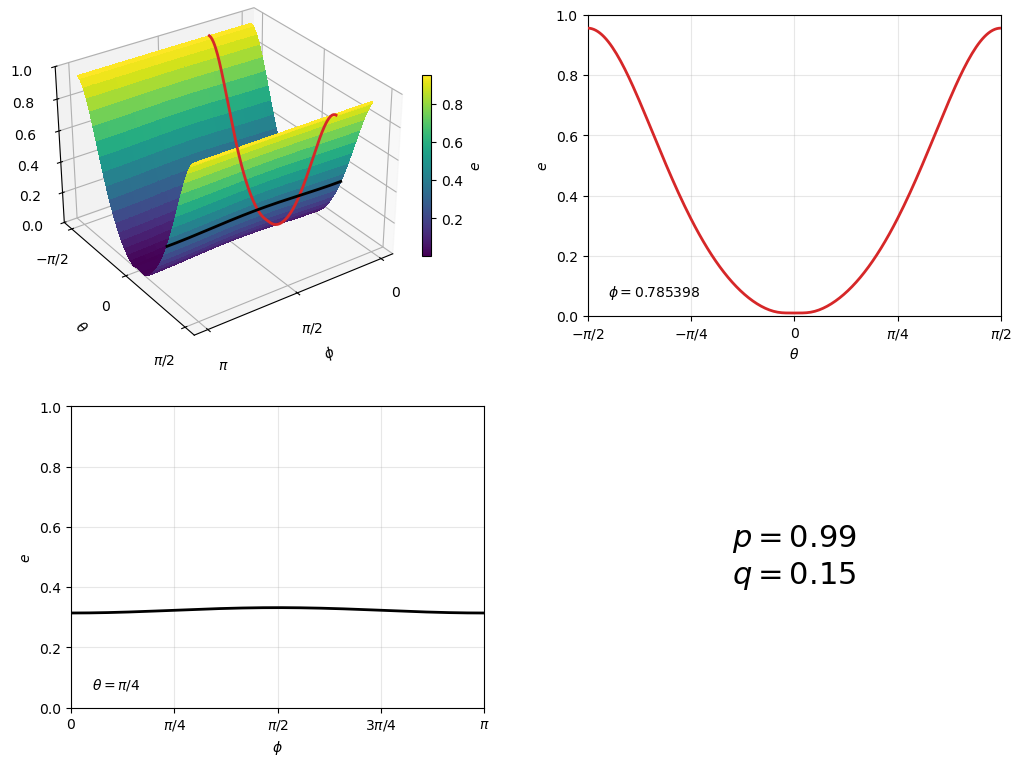

In [78]:
p = 0.99
q = 0.15
PHI0 = np.pi/4
THETA0 = np.pi/4
C_PHI, C_TH = "tab:red", "k"
EMAX = 1.0

n = 201
phi = np.linspace(0, np.pi, n)
theta = np.linspace(-np.pi/2, np.pi/2, n)
PHI, THETA = np.meshgrid(phi, theta)

E = ellipticity(PHI, THETA, p, q)
E_phi0 = ellipticity(PHI0, theta, p, q)
E_th0 = ellipticity(phi, THETA0, p, q)

fig = plt.figure(figsize=(12, 9))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)

# 3D
ax3d = fig.add_subplot(gs[0, 0], projection="3d")
ax3d.computed_zorder = False   # honour zorder instead of depth-sorting artists
ax3d.set_box_aspect(None, zoom=1.25)
surf = ax3d.plot_surface(PHI, THETA, E, cmap="viridis",
                         linewidth=0, antialiased=False, zorder=1)
ax3d.plot(np.full_like(theta, PHI0), theta, E_phi0, color=C_PHI, lw=2, zorder=10)
ax3d.plot(phi, np.full_like(phi, THETA0), E_th0, color=C_TH, lw=2, zorder=10)
ax3d.set_xlabel(r"$\phi$")
ax3d.set_ylabel(r"$\theta$")
ax3d.set_zlabel(r"$e$")
ax3d.set_xticks([0, np.pi / 2, np.pi])
ax3d.set_xticklabels(["0", r"$\pi/2$", r"$\pi$"])
ax3d.set_yticks([-np.pi / 2, 0, np.pi / 2])
ax3d.set_yticklabels([r"$-\pi/2$", "0", r"$\pi/2$"])
ax3d.set_zlim(0, EMAX)
ax3d.view_init(elev=30, azim=55)
fig.colorbar(surf, ax=ax3d, shrink=0.6, pad=0.12, label=r"$e$")

# upper right: ellipticity vs theta at fixed phi
ax_r = fig.add_subplot(gs[0, 1])
ax_r.plot(theta, E_phi0, color=C_PHI, lw=2, zorder=10)
ax_r.set_xlabel(r"$\theta$")
ax_r.set_ylabel(r"$e$")
ax_r.text(0.05, 0.05, rf"$\phi = {PHI0:g}$", transform=ax_r.transAxes, va='bottom', ha='left')
ax_r.set_xlim(-np.pi / 2, np.pi / 2)
ax_r.set_xticks([-np.pi / 2, -np.pi / 4, 0, np.pi / 4, np.pi / 2])
ax_r.set_xticklabels([r"$-\pi/2$", r"$-\pi/4$", "0", r"$\pi/4$", r"$\pi/2$"])
ax_r.set_ylim(0, EMAX)
ax_r.grid(alpha=0.3)
 
# lower left: ellipticity vs phi at fixed theta
ax_l = fig.add_subplot(gs[1, 0])
ax_l.plot(phi, E_th0, color=C_TH, lw=2)
ax_l.set_xlabel(r"$\phi$")
ax_l.set_ylabel(r"$e$")
ax_l.text(0.05, 0.05, r"$\theta = \pi/4$", transform=ax_l.transAxes, va='bottom', ha='left')
ax_l.set_xlim(0, np.pi)
ax_l.set_xticks([0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
ax_l.set_xticklabels(["0", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"])
ax_l.set_ylim(0, EMAX)
ax_l.grid(alpha=0.3)

ax_info = fig.add_subplot(gs[1, 1])
ax_info.axis("off")
ax_info.text(0.5, 0.5, f"$p = {p:g}$\n$q = {q:g}$", ha="center", va="center",
        fontsize=22, transform=ax_info.transAxes)
plt.show()

# Derivative

In [ ]:
import sympy as sp
p, q, phi, theta = sp.symbols('p q phi theta')
j = q**2 * sp.sin(theta)**2 \
    + p**2 * sp.sin(phi)**2 * sp.cos(theta)**2 \
    + sp.cos(phi)**2 * sp.cos(theta)**2
l = p**2 * sp.cos(phi)**2 + sp.sin(phi)**2
k = (1 - p**2) * sp.sin(phi) * sp.cos(phi) * sp.cos(theta)

a = sp.sqrt((j-l)**2 + 4*k**2)
Q = sp.sqrt((j+l-a)/(j+l+a))
e = (1-Q**2)/(1+Q**2)

## axis ratio
How does $\varphi$-averaged $Q$ change with respect to $\theta$ in the first order of $p$?

Taylor expansion of $\langle Q\rangle_\varphi$ at $p=1$ is 
$$\langle Q\rangle_\varphi = \langle Q\rangle_\varphi\vert_{p=1} + \left.\frac{\partial \langle Q\rangle_\varphi}{\partial p}\right\vert_{p=1}\ (p-1) + \mathcal{O}(p^2)$$
where $\frac{\partial \langle Q\rangle_\varphi}{\partial p} = \left\langle \frac{\partial Q}{\partial p}\right\rangle_\varphi$

$\langle Q\rangle_\varphi\vert_{p=1} = Q(p=1) = \sqrt{q^2\sin^2\theta + \cos^2\theta}$

In [ ]:
dQ_dp = sp.diff(Q, p)

p0 = 1
Q0 = sp.simplify(Q.subs(p, p0))

dQdp_p0 = sp.simplify(dQ_dp.subs(p, p0))

C1 = sp.integrate(dQdp_p0, (phi, 0, sp.pi)) / sp.pi
C1 = sp.simplify(C1)

p_sym = sp.symbols("p")
Q_taylor1 = Q0 + C1 * (p_sym - p0)
sp.simplify(Q_taylor1)

sqrt((q**2*sin(theta)**2 - sqrt((q**4 - 2*q**2 + 1)*sin(theta)**4) - sin(theta)**2 + 2)/(q**2*sin(theta)**2 + sqrt((q**4 - 2*q**2 + 1)*sin(theta)**4) - sin(theta)**2 + 2))*(q**4*sin(theta)**2 + q**2*sqrt((q**4 - 2*q**2 + 1)*sin(theta)**4)*(p - 1)/2 - 2*q**2*sin(theta)**2 + q**2 + sin(theta)**2 - 1)/(q**4*sin(theta)**2 - 2*q**2*sin(theta)**2 + q**2 + sin(theta)**2 - 1)

In [17]:
sp.simplify(C1.subs(q, 0.15))

0.010996875*sqrt((-0.9775*sqrt(sin(theta)**4) - 0.9775*sin(theta)**2 + 2.0)/(0.9775*sqrt(sin(theta)**4) - 0.9775*sin(theta)**2 + 2.0))*sqrt(sin(theta)**4)/(0.95550625*sin(theta)**2 - 0.9775)

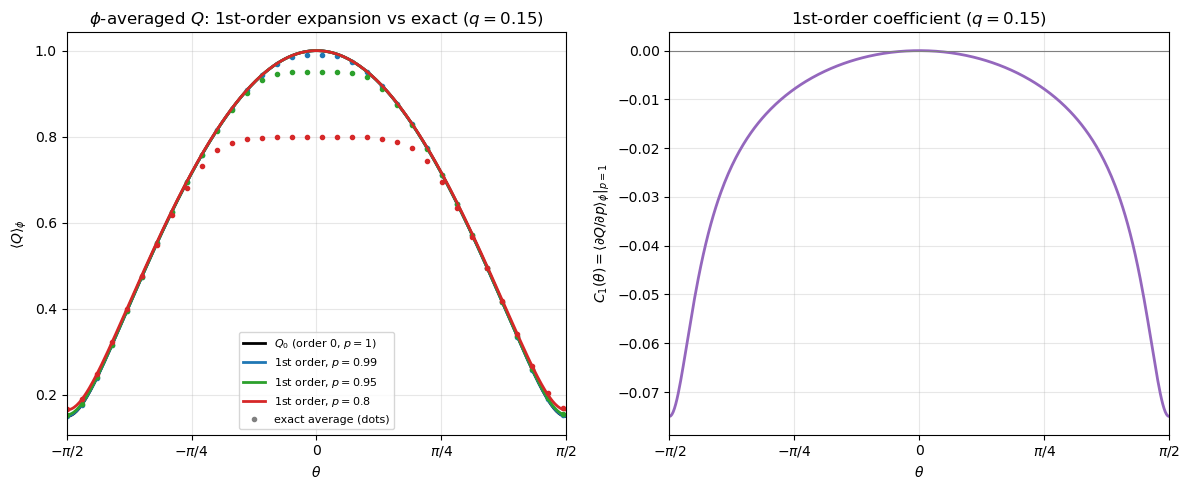

In [ ]:
q_value = sp.Rational(15, 100)
Q0_np = sp.lambdify(theta, Q0.subs(q, q_value), "numpy")
C1_np = sp.lambdify(theta, C1.subs(q, q_value), "numpy")
Q_taylor1_np = sp.lambdify((theta, p_sym), Q_taylor1.subs(q, q_value), "numpy")
Q_num = sp.lambdify((phi, theta, p), Q.subs(q, q_value), "numpy")

def avgQ(theta_arr, p_val, n_phi=4001):
    """exact (1/pi) int_0^pi Q dphi at q = 0.15, by quadrature."""
    ph = np.linspace(0, np.pi, n_phi)
    PH, TH = np.meshgrid(ph, np.atleast_1d(theta_arr))
    with np.errstate(divide="ignore", invalid="ignore"):
        Z = Q_num(PH, TH, p_val)
    return np.trapezoid(Z, ph, axis=1) / (ph[-1] - ph[0])


th = np.linspace(-np.pi / 2, np.pi / 2, 400)   # even count: skips theta = 0
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, 5))
 
# left: expansion vs exact average, at a few p
axA.plot(th, Q0_np(th), color="k", lw=2, label=r"$Q_0$ (order 0, $p=1$)")
for pv, col in [(0.99, "tab:blue"), (0.95, "tab:green"), (0.8, "tab:red")]:
    axA.plot(th, Q_taylor1_np(th, pv), color=col, lw=2,
             label=rf"1st order, $p={pv}$")
    axA.plot(th, avgQ(th, pv), color=col, lw=0, marker="o", ms=3, markevery=12)
axA.plot([], [], color="0.5", marker="o", ms=3, lw=0, label="exact average (dots)")
axA.set_xlabel(r"$\theta$")
axA.set_ylabel(r"$\langle Q \rangle_\phi$")
axA.set_title(r"$\phi$-averaged $Q$: 1st-order expansion vs exact ($q=0.15$)")
axA.set_xlim(-np.pi / 2, np.pi / 2)
axA.set_xticks([-np.pi/2, -np.pi/4, 0, np.pi/4, np.pi/2])
axA.set_xticklabels([r"$-\pi/2$", r"$-\pi/4$", "0", r"$\pi/4$", r"$\pi/2$"])
axA.grid(alpha=0.3)
axA.legend(fontsize=8)
 
# right: the coefficient C1(theta)
axB.plot(th, C1_np(th), color="tab:purple", lw=2)
axB.axhline(0, color="0.5", lw=0.8)
axB.set_xlabel(r"$\theta$")
axB.set_ylabel(r"$C_1(\theta) = \langle \partial Q/\partial p\rangle_\phi|_{p=1}$")
axB.set_title(r"1st-order coefficient ($q=0.15$)")
axB.set_xlim(-np.pi / 2, np.pi / 2)
axB.set_xticks([-np.pi/2, -np.pi/4, 0, np.pi/4, np.pi/2])
axB.set_xticklabels([r"$-\pi/2$", r"$-\pi/4$", "0", r"$\pi/4$", r"$\pi/2$"])
axB.grid(alpha=0.3)
 
fig.tight_layout()
plt.show()

## ellipticity
See the response of ellipticity to the small change in $p$
$$\delta e = \frac{\partial e}{\partial p} \delta p$$
as a function of $(\varphi, \theta)$ and some given $q$

In [ ]:
de_dp = sp.diff(e, p)
de_dp_num = sp.lambdify((phi, theta, p, q), de_dp, modules='numpy', cse=True)


In [4]:
def pi_label(x):
    return sp.latex(sp.nsimplify(x / np.pi, rational=True, tolerance=1e-9) * sp.pi,
                    fold_short_frac=True)

def dedp(ph, th):
    """de/dp at (p_value, q_value); singular points (0/0, inf) become NaN, i.e. gaps."""
    with np.errstate(divide="ignore", invalid="ignore"):
        out = de_dp_num(ph, th, p_value, q_value)
    return np.where(np.isfinite(out), out, np.nan)

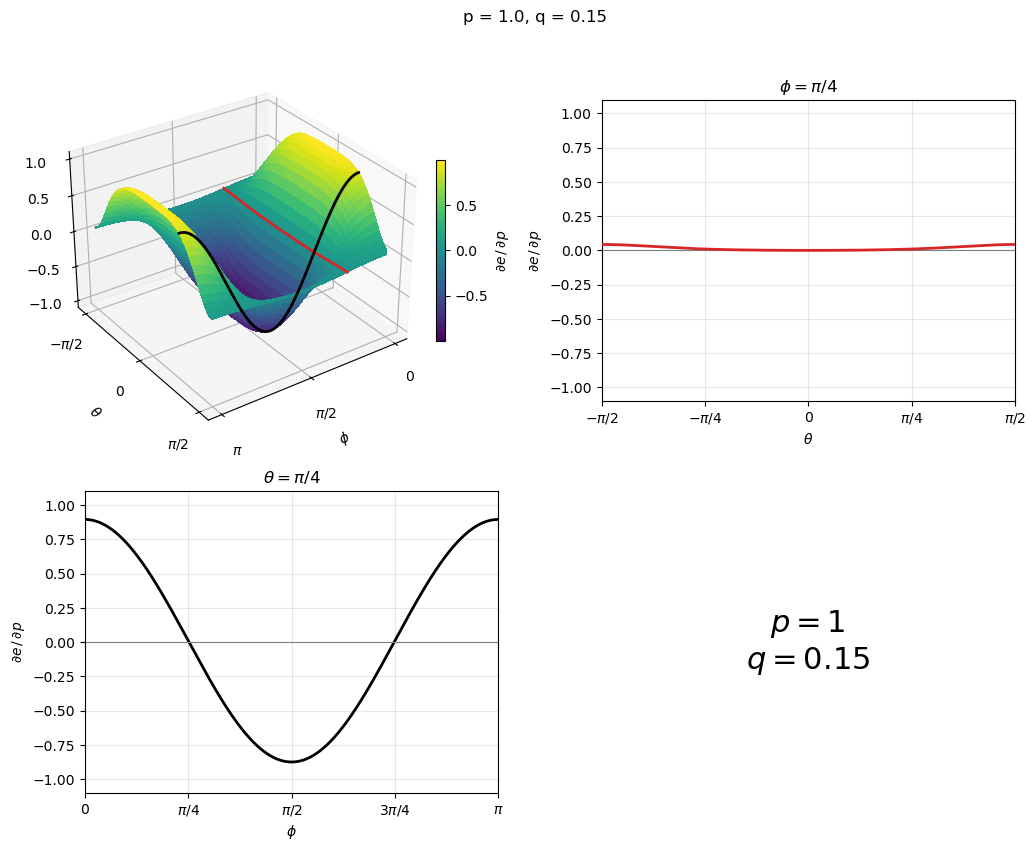

In [5]:
p_value, q_value = 1.0, 0.15
PHI0 = np.pi / 4      # fixed phi   for the upper-right panel
THETA0 = np.pi / 4    # fixed theta for the lower-left panel
n = 180               # EVEN on purpose: the grid then never hits theta = 0 exactly,
n1 = 1000             # where de/dp is 0/0 at p = 1 (see notes)
 
phi_g = np.linspace(0, np.pi, n)
theta_g = np.linspace(-np.pi / 2, np.pi / 2, n)
PHI, THETA = np.meshgrid(phi_g, theta_g)  # arrays of shape (len(theta), len(phi))
 
phi1 = np.linspace(0, np.pi, n1)
theta1 = np.linspace(-np.pi / 2, np.pi / 2, n1)
 
 
Z = dedp(PHI, THETA)
Z_phi0 = dedp(PHI0, theta1)      # de/dp vs theta at phi   = PHI0
Z_th0 = dedp(phi1, THETA0)       # de/dp vs phi   at theta = THETA0
 
ZMAX = 1.1 * np.nanmax(np.abs(Z))     # symmetric limit of the 3D z-axis
YLAB = r"$\partial e\,/\,\partial p$"
SHARE_YLIM = True   # True: 2D panels use the same +-ZMAX range as the 3D panel; False: autoscale
C_PHI, C_TH = "tab:red", "k"          # slice colours, shared by 3D and 2D panels
 

fig = plt.figure(figsize=(12, 9))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)
 
# upper left: 3D surface with the two slices marked
ax3d = fig.add_subplot(gs[0, 0], projection="3d")
ax3d.computed_zorder = False   # honour zorder instead of depth-sorting artists
ax3d.set_box_aspect(None, zoom=1.25)
surf = ax3d.plot_surface(PHI, THETA, Z, cmap="viridis",
                         linewidth=0, antialiased=False, zorder=1)
ax3d.plot(np.full_like(theta1, PHI0), theta1, Z_phi0, color=C_PHI, lw=2, zorder=10)
ax3d.plot(phi1, np.full_like(phi1, THETA0), Z_th0, color=C_TH, lw=2, zorder=10)
ax3d.set_xlabel(r"$\phi$")
ax3d.set_ylabel(r"$\theta$")
ax3d.set_zlabel(YLAB, labelpad=8)
ax3d.set_xticks([0, np.pi / 2, np.pi])
ax3d.set_xticklabels(["0", r"$\pi/2$", r"$\pi$"])
ax3d.set_yticks([-np.pi / 2, 0, np.pi / 2])
ax3d.set_yticklabels([r"$-\pi/2$", "0", r"$\pi/2$"])
ax3d.set_zlim(-ZMAX, ZMAX)
ax3d.view_init(elev=30, azim=55)   # phi: pi -> 0 left to right; theta: -pi/2 -> pi/2 far to near
fig.colorbar(surf, ax=ax3d, shrink=0.6, pad=0.12, label=YLAB)
 
# upper right: de/dp vs theta at fixed phi
ax_r = fig.add_subplot(gs[0, 1])
ax_r.plot(theta1, Z_phi0, color=C_PHI, lw=2, zorder=10)
ax_r.axhline(0, color="0.5", lw=0.8)
ax_r.set_xlabel(r"$\theta$")
ax_r.set_ylabel(YLAB)
ax_r.set_title(rf"$\phi = {pi_label(PHI0)}$")
ax_r.set_xlim(-np.pi / 2, np.pi / 2)
ax_r.set_xticks([-np.pi / 2, -np.pi / 4, 0, np.pi / 4, np.pi / 2])
ax_r.set_xticklabels([r"$-\pi/2$", r"$-\pi/4$", "0", r"$\pi/4$", r"$\pi/2$"])
if SHARE_YLIM:
    ax_r.set_ylim(-ZMAX, ZMAX)
ax_r.grid(alpha=0.3)
 
# lower left: de/dp vs phi at fixed theta
ax_l = fig.add_subplot(gs[1, 0])
ax_l.plot(phi1, Z_th0, color=C_TH, lw=2)
ax_l.axhline(0, color="0.5", lw=0.8)
ax_l.set_xlabel(r"$\phi$")
ax_l.set_ylabel(YLAB)
ax_l.set_title(rf"$\theta = {pi_label(THETA0)}$")
ax_l.set_xlim(0, np.pi)
ax_l.set_xticks([0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
ax_l.set_xticklabels(["0", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"])
if SHARE_YLIM:
    ax_l.set_ylim(-ZMAX, ZMAX)
ax_l.grid(alpha=0.3)
 
# lower right: text panel with the model parameters
ax_info = fig.add_subplot(gs[1, 1])
ax_info.axis("off")
ax_info.text(0.5, 0.5, f"$p = {p_value:g}$\n$q = {q_value:g}$", ha="center", va="center",
             fontsize=22, transform=ax_info.transAxes)
 
fig.suptitle(f"p = {p_value}, q = {q_value}")
plt.show()

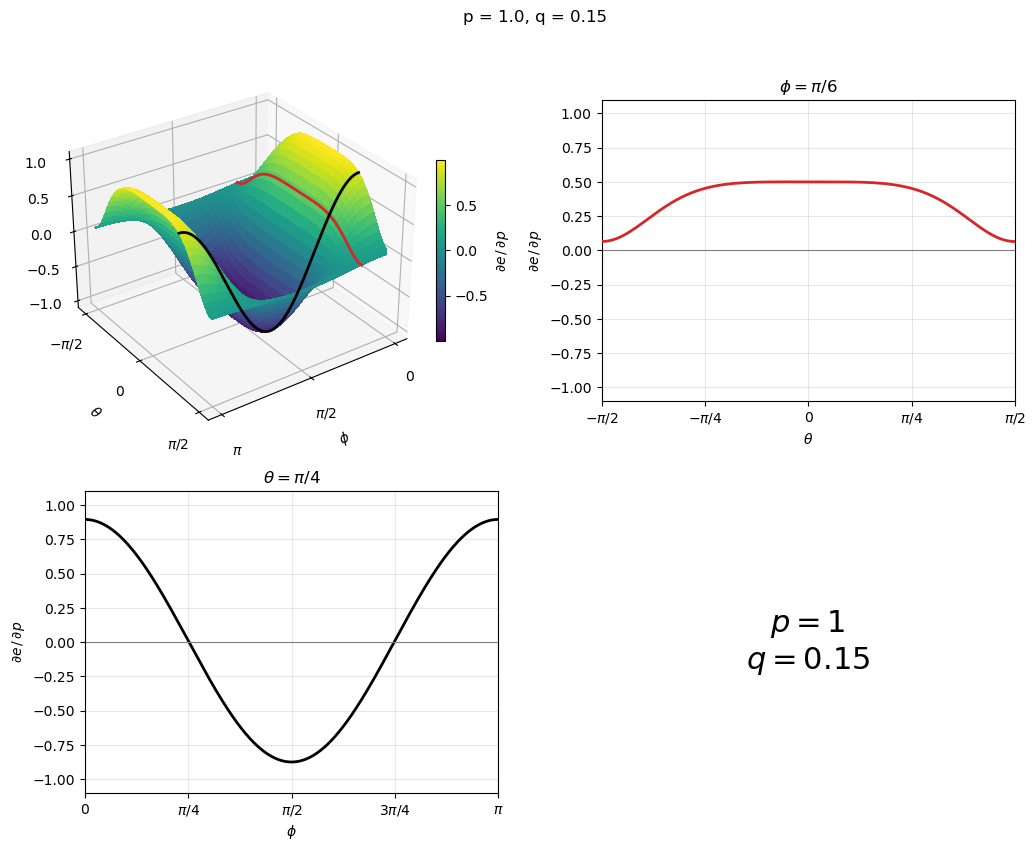

In [6]:
p_value, q_value = 1.0, 0.15
PHI0 = np.pi/6      # fixed phi   for the upper-right panel
THETA0 = np.pi / 4    # fixed theta for the lower-left panel
n = 180               # EVEN on purpose: the grid then never hits theta = 0 exactly,
n1 = 1000             # where de/dp is 0/0 at p = 1 (see notes)
 
phi_g = np.linspace(0, np.pi, n)
theta_g = np.linspace(-np.pi / 2, np.pi / 2, n)
PHI, THETA = np.meshgrid(phi_g, theta_g)  # arrays of shape (len(theta), len(phi))
 
phi1 = np.linspace(0, np.pi, n1)
theta1 = np.linspace(-np.pi / 2, np.pi / 2, n1)
 
 
Z = dedp(PHI, THETA)
Z_phi0 = dedp(PHI0, theta1)      # de/dp vs theta at phi   = PHI0
Z_th0 = dedp(phi1, THETA0)       # de/dp vs phi   at theta = THETA0
 
ZMAX = 1.1 * np.nanmax(np.abs(Z))     # symmetric limit of the 3D z-axis
YLAB = r"$\partial e\,/\,\partial p$"
SHARE_YLIM = True   # True: 2D panels use the same +-ZMAX range as the 3D panel; False: autoscale
C_PHI, C_TH = "tab:red", "k"          # slice colours, shared by 3D and 2D panels
 

fig = plt.figure(figsize=(12, 9))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)
 
# upper left: 3D surface with the two slices marked
ax3d = fig.add_subplot(gs[0, 0], projection="3d")
ax3d.computed_zorder = False   # honour zorder instead of depth-sorting artists
ax3d.set_box_aspect(None, zoom=1.25)
surf = ax3d.plot_surface(PHI, THETA, Z, cmap="viridis",
                         linewidth=0, antialiased=False, zorder=1)
ax3d.plot(np.full_like(theta1, PHI0), theta1, Z_phi0, color=C_PHI, lw=2, zorder=10)
ax3d.plot(phi1, np.full_like(phi1, THETA0), Z_th0, color=C_TH, lw=2, zorder=10)
ax3d.set_xlabel(r"$\phi$")
ax3d.set_ylabel(r"$\theta$")
ax3d.set_zlabel(YLAB, labelpad=8)
ax3d.set_xticks([0, np.pi / 2, np.pi])
ax3d.set_xticklabels(["0", r"$\pi/2$", r"$\pi$"])
ax3d.set_yticks([-np.pi / 2, 0, np.pi / 2])
ax3d.set_yticklabels([r"$-\pi/2$", "0", r"$\pi/2$"])
ax3d.set_zlim(-ZMAX, ZMAX)
ax3d.view_init(elev=30, azim=55)   # phi: pi -> 0 left to right; theta: -pi/2 -> pi/2 far to near
fig.colorbar(surf, ax=ax3d, shrink=0.6, pad=0.12, label=YLAB)
 
# upper right: de/dp vs theta at fixed phi
ax_r = fig.add_subplot(gs[0, 1])
ax_r.plot(theta1, Z_phi0, color=C_PHI, lw=2, zorder=10)
ax_r.axhline(0, color="0.5", lw=0.8)
ax_r.set_xlabel(r"$\theta$")
ax_r.set_ylabel(YLAB)
ax_r.set_title(rf"$\phi = {pi_label(PHI0)}$")
ax_r.set_xlim(-np.pi / 2, np.pi / 2)
ax_r.set_xticks([-np.pi / 2, -np.pi / 4, 0, np.pi / 4, np.pi / 2])
ax_r.set_xticklabels([r"$-\pi/2$", r"$-\pi/4$", "0", r"$\pi/4$", r"$\pi/2$"])
if SHARE_YLIM:
    ax_r.set_ylim(-ZMAX, ZMAX)
ax_r.grid(alpha=0.3)
 
# lower left: de/dp vs phi at fixed theta
ax_l = fig.add_subplot(gs[1, 0])
ax_l.plot(phi1, Z_th0, color=C_TH, lw=2)
ax_l.axhline(0, color="0.5", lw=0.8)
ax_l.set_xlabel(r"$\phi$")
ax_l.set_ylabel(YLAB)
ax_l.set_title(rf"$\theta = {pi_label(THETA0)}$")
ax_l.set_xlim(0, np.pi)
ax_l.set_xticks([0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
ax_l.set_xticklabels(["0", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"])
if SHARE_YLIM:
    ax_l.set_ylim(-ZMAX, ZMAX)
ax_l.grid(alpha=0.3)
 
# lower right: text panel with the model parameters
ax_info = fig.add_subplot(gs[1, 1])
ax_info.axis("off")
ax_info.text(0.5, 0.5, f"$p = {p_value:g}$\n$q = {q_value:g}$", ha="center", va="center",
             fontsize=22, transform=ax_info.transAxes)
 
fig.suptitle(f"p = {p_value}, q = {q_value}")
plt.show()

## shear
The tangential shear component, in the first order, is
$$g_+ = \frac{e_{\rm obs}-e}{2(1-e^2)}$$
The response to $\delta p$ is written as
$$\delta g_+ = \frac{\partial g_+}{\partial e} \frac{\partial e}{\partial p} \delta p$$
We estimate the response at $g_+=0.01$, a typical shear signal. We assume no preferred direction for the non-circular disk, hence we estimate the averaged shear response over uniform $\varphi\in (0, \pi)$ 
$$\left\langle \frac{\partial g_+}{\partial e} \right\rangle_\varphi = \displaystyle\frac{1}{\pi}\int \frac{\partial g_+}{\partial e} d\varphi$$

In [7]:
G0 = sp.Rational(1, 100)

eobs = sp.symbols('e_obs', real=True)
gplus = (eobs - e) / (2*(1 - e**2))

eobs_at_g0 = sp.solve(sp.Eq(gplus, G0), eobs)[0]
dgplus_dp = sp.diff(gplus, p).subs(eobs, eobs_at_g0)

dgplus_dp_num = sp.lambdify((phi, theta, p, q), dgplus_dp, modules="numpy", cse=True)

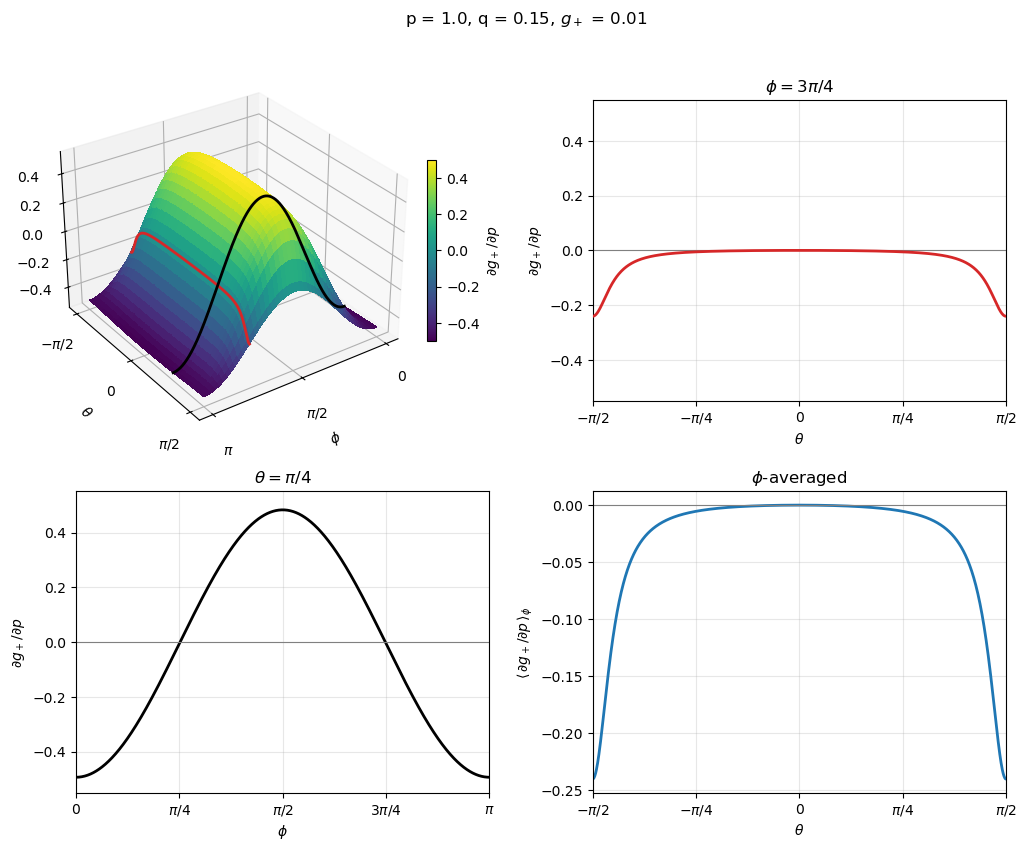

In [8]:
p_value, q_value = 1.0, 0.15
g0_value = float(G0)
PHI0 = np.pi / 4  * 3    # fixed phi   for the upper-right panel
THETA0 = np.pi / 4    # fixed theta for the lower-left panel
n = 180               # EVEN on purpose: grid never lands on theta = 0, where de/dp
n1 = 1000             # is singular at p = 1 (see notes)
SHARE_YLIM = True    # True: 2D panels share the +-ZMAX range; False: autoscale


phi_g = np.linspace(0, np.pi, n)
theta_g = np.linspace(-np.pi / 2, np.pi / 2, n)
PHI, THETA = np.meshgrid(phi_g, theta_g)  # arrays of shape (len(theta), len(phi))
 
phi1 = np.linspace(0, np.pi, n1)
theta1 = np.linspace(-np.pi / 2, np.pi / 2, n1)
 
 
def dgdp(ph, th):
    """d gplus/dp at (p_value, q_value, gplus=g0); singular points -> NaN (gaps)."""
    with np.errstate(divide="ignore", invalid="ignore"):
        out = dgplus_dp_num(ph, th, p_value, q_value)
    return np.where(np.isfinite(out), out, np.nan)
 

Z = dgdp(PHI, THETA)
Z_phi0 = dgdp(PHI0, theta1)      # vs theta at phi   = PHI0
Z_th0 = dgdp(phi1, THETA0)       # vs phi   at theta = THETA0

PHI_A, TH_A = np.meshgrid(phi1, theta1)                 # (len(theta1), len(phi1))
with np.errstate(divide="ignore", invalid="ignore"):
    Z_A = dgplus_dp_num(PHI_A, TH_A, p_value, q_value)

dgdp_phiavg = np.trapezoid(Z_A, phi1, axis=1) / (phi1[-1] - phi1[0])
dgdp_phi_sigma = np.sqrt(np.trapezoid((Z_A-dgdp_phiavg[:,None])**2, phi1, axis=1) / (phi1[-1] - phi1[0]))
 
ZMAX = 1.1 * np.nanmax(np.abs(Z))     # symmetric limit of the 3D z-axis
YLAB = r"$\partial g_+ / \partial p$"
C_PHI, C_TH = "tab:red", "k"          # slice colours, shared by 3D and 2D panels
 
# ---------------------------------------------------------------- figure: 2 x 2 grid
fig = plt.figure(figsize=(12, 9))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)
 
# upper left: 3D surface with the two slices marked
ax3d = fig.add_subplot(gs[0, 0], projection="3d")
ax3d.computed_zorder = False   # honour zorder instead of depth-sorting artists
ax3d.set_box_aspect(None, zoom=1.25)
surf = ax3d.plot_surface(PHI, THETA, Z, cmap="viridis",
                         linewidth=0, antialiased=False, zorder=1)
ax3d.plot(np.full_like(theta1, PHI0), theta1, Z_phi0, color=C_PHI, lw=2, zorder=10)
ax3d.plot(phi1, np.full_like(phi1, THETA0), Z_th0, color=C_TH, lw=2, zorder=10)
ax3d.set_xlabel(r"$\phi$")
ax3d.set_ylabel(r"$\theta$")
ax3d.set_zlabel(YLAB, labelpad=8)
ax3d.set_xticks([0, np.pi / 2, np.pi])
ax3d.set_xticklabels(["0", r"$\pi/2$", r"$\pi$"])
ax3d.set_yticks([-np.pi / 2, 0, np.pi / 2])
ax3d.set_yticklabels([r"$-\pi/2$", "0", r"$\pi/2$"])
ax3d.set_zlim(-ZMAX, ZMAX)
ax3d.view_init(elev=30, azim=55)   # phi: pi -> 0 left to right; theta: -pi/2 -> pi/2 far to near
fig.colorbar(surf, ax=ax3d, shrink=0.6, pad=0.12, label=YLAB)
 
# upper right: vs theta at fixed phi
ax_r = fig.add_subplot(gs[0, 1])
ax_r.plot(theta1, Z_phi0, color=C_PHI, lw=2, zorder=10)
ax_r.axhline(0, color="0.5", lw=0.8)
ax_r.set_xlabel(r"$\theta$")
ax_r.set_ylabel(YLAB)
ax_r.set_title(rf"$\phi = {pi_label(PHI0)}$")
ax_r.set_xlim(-np.pi / 2, np.pi / 2)
ax_r.set_xticks([-np.pi / 2, -np.pi / 4, 0, np.pi / 4, np.pi / 2])
ax_r.set_xticklabels([r"$-\pi/2$", r"$-\pi/4$", "0", r"$\pi/4$", r"$\pi/2$"])
if SHARE_YLIM:
    ax_r.set_ylim(-ZMAX, ZMAX)
ax_r.grid(alpha=0.3)
 
# lower left: vs phi at fixed theta
ax_l = fig.add_subplot(gs[1, 0])
ax_l.plot(phi1, Z_th0, color=C_TH, lw=2)
ax_l.axhline(0, color="0.5", lw=0.8)
ax_l.set_xlabel(r"$\phi$")
ax_l.set_ylabel(YLAB)
ax_l.set_title(rf"$\theta = {pi_label(THETA0)}$")
ax_l.set_xlim(0, np.pi)
ax_l.set_xticks([0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
ax_l.set_xticklabels(["0", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"])
if SHARE_YLIM:
    ax_l.set_ylim(-ZMAX, ZMAX)
ax_l.grid(alpha=0.3)
 
# lower right: text panel with the model parameters and the fixed gplus
ax_info = fig.add_subplot(gs[1, 1])
ax_info.axis("off")
ax_info.text(0.5, 0.5, f"$p = {p_value:g}$\n$q = {q_value:g}$\n$g_+ = {g0_value:g}$",
             ha="center", va="center", fontsize=22, transform=ax_info.transAxes)

ax_avg = fig.add_subplot(gs[1, 1])
ax_avg.plot(theta1, dgdp_phiavg, color="tab:blue", lw=2)
ax_avg.axhline(0, color="0.5", lw=0.8)
ax_avg.set_xlabel(r"$\theta$")
ax_avg.set_ylabel(r"$\langle\, \partial g_+ / \partial p \,\rangle_\phi$")
ax_avg.set_title(rf"$\phi$-averaged")
ax_avg.set_xlim(-np.pi / 2, np.pi / 2)
ax_avg.set_xticks([-np.pi / 2, -np.pi / 4, 0, np.pi / 4, np.pi / 2])
ax_avg.set_xticklabels([r"$-\pi/2$", r"$-\pi/4$", "0", r"$\pi/4$", r"$\pi/2$"])
ax_avg.grid(alpha=0.3)

# ax_avg.fill_between(theta1, dgdp_phiavg+dgdp_phi_sigma, dgdp_phiavg-dgdp_phi_sigma, 
#                     color="tab:blue", alpha=0.2, label=r"$\pm 1\sigma_\phi$")
# ax_avg.legend(loc="lower center", frameon=False)
 
fig.suptitle(f"p = {p_value}, q = {q_value}, $g_+$ = {g0_value:g}")
plt.show()

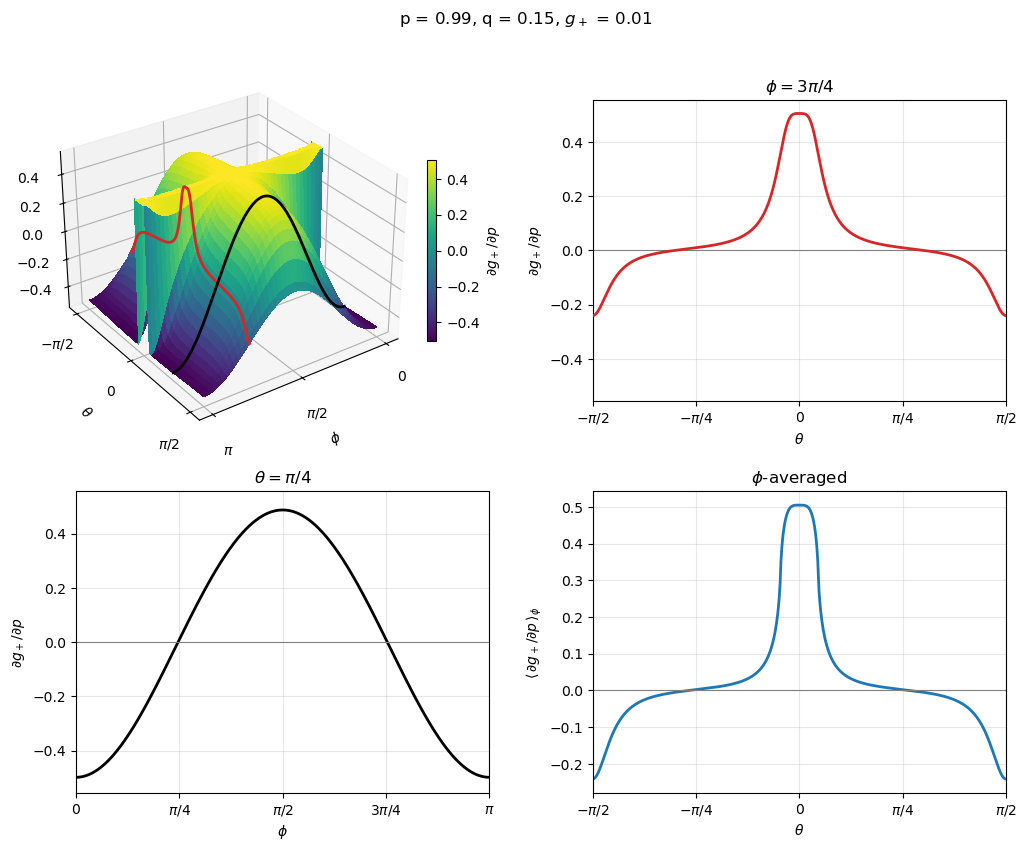

In [124]:
p_value, q_value = 0.99, 0.15
g0_value = float(G0)
PHI0 = np.pi / 4  * 3    # fixed phi   for the upper-right panel
THETA0 = np.pi / 4    # fixed theta for the lower-left panel
n = 180               # EVEN on purpose: grid never lands on theta = 0, where de/dp
n1 = 1000             # is singular at p = 1 (see notes)
SHARE_YLIM = True    # True: 2D panels share the +-ZMAX range; False: autoscale


phi_g = np.linspace(0, np.pi, n)
theta_g = np.linspace(-np.pi / 2, np.pi / 2, n)
PHI, THETA = np.meshgrid(phi_g, theta_g)  # arrays of shape (len(theta), len(phi))
 
phi1 = np.linspace(0, np.pi, n1)
theta1 = np.linspace(-np.pi / 2, np.pi / 2, n1)
 
 
def dgdp(ph, th):
    """d gplus/dp at (p_value, q_value, gplus=g0); singular points -> NaN (gaps)."""
    with np.errstate(divide="ignore", invalid="ignore"):
        out = dgplus_dp_num(ph, th, p_value, q_value)
    return np.where(np.isfinite(out), out, np.nan)
 

Z = dgdp(PHI, THETA)
Z_phi0 = dgdp(PHI0, theta1)      # vs theta at phi   = PHI0
Z_th0 = dgdp(phi1, THETA0)       # vs phi   at theta = THETA0

PHI_A, TH_A = np.meshgrid(phi1, theta1)                 # (len(theta1), len(phi1))
with np.errstate(divide="ignore", invalid="ignore"):
    Z_A = dgplus_dp_num(PHI_A, TH_A, p_value, q_value)

dgdp_phiavg = np.trapezoid(Z_A, phi1, axis=1) / (phi1[-1] - phi1[0])
dgdp_phi_sigma = np.sqrt(np.trapezoid((Z_A-dgdp_phiavg[:,None])**2, phi1, axis=1) / (phi1[-1] - phi1[0]))
 
ZMAX = 1.1 * np.nanmax(np.abs(Z))     # symmetric limit of the 3D z-axis
YLAB = r"$\partial g_+ / \partial p$"
C_PHI, C_TH = "tab:red", "k"          # slice colours, shared by 3D and 2D panels
 
# ---------------------------------------------------------------- figure: 2 x 2 grid
fig = plt.figure(figsize=(12, 9))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)
 
# upper left: 3D surface with the two slices marked
ax3d = fig.add_subplot(gs[0, 0], projection="3d")
ax3d.computed_zorder = False   # honour zorder instead of depth-sorting artists
ax3d.set_box_aspect(None, zoom=1.25)
surf = ax3d.plot_surface(PHI, THETA, Z, cmap="viridis",
                         linewidth=0, antialiased=False, zorder=1)
ax3d.plot(np.full_like(theta1, PHI0), theta1, Z_phi0, color=C_PHI, lw=2, zorder=10)
ax3d.plot(phi1, np.full_like(phi1, THETA0), Z_th0, color=C_TH, lw=2, zorder=10)
ax3d.set_xlabel(r"$\phi$")
ax3d.set_ylabel(r"$\theta$")
ax3d.set_zlabel(YLAB, labelpad=8)
ax3d.set_xticks([0, np.pi / 2, np.pi])
ax3d.set_xticklabels(["0", r"$\pi/2$", r"$\pi$"])
ax3d.set_yticks([-np.pi / 2, 0, np.pi / 2])
ax3d.set_yticklabels([r"$-\pi/2$", "0", r"$\pi/2$"])
ax3d.set_zlim(-ZMAX, ZMAX)
ax3d.view_init(elev=30, azim=55)   # phi: pi -> 0 left to right; theta: -pi/2 -> pi/2 far to near
fig.colorbar(surf, ax=ax3d, shrink=0.6, pad=0.12, label=YLAB)
 
# upper right: vs theta at fixed phi
ax_r = fig.add_subplot(gs[0, 1])
ax_r.plot(theta1, Z_phi0, color=C_PHI, lw=2, zorder=10)
ax_r.axhline(0, color="0.5", lw=0.8)
ax_r.set_xlabel(r"$\theta$")
ax_r.set_ylabel(YLAB)
ax_r.set_title(rf"$\phi = {pi_label(PHI0)}$")
ax_r.set_xlim(-np.pi / 2, np.pi / 2)
ax_r.set_xticks([-np.pi / 2, -np.pi / 4, 0, np.pi / 4, np.pi / 2])
ax_r.set_xticklabels([r"$-\pi/2$", r"$-\pi/4$", "0", r"$\pi/4$", r"$\pi/2$"])
if SHARE_YLIM:
    ax_r.set_ylim(-ZMAX, ZMAX)
ax_r.grid(alpha=0.3)
 
# lower left: vs phi at fixed theta
ax_l = fig.add_subplot(gs[1, 0])
ax_l.plot(phi1, Z_th0, color=C_TH, lw=2)
ax_l.axhline(0, color="0.5", lw=0.8)
ax_l.set_xlabel(r"$\phi$")
ax_l.set_ylabel(YLAB)
ax_l.set_title(rf"$\theta = {pi_label(THETA0)}$")
ax_l.set_xlim(0, np.pi)
ax_l.set_xticks([0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
ax_l.set_xticklabels(["0", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"])
if SHARE_YLIM:
    ax_l.set_ylim(-ZMAX, ZMAX)
ax_l.grid(alpha=0.3)
 
# lower right: text panel with the model parameters and the fixed gplus
ax_info = fig.add_subplot(gs[1, 1])
ax_info.axis("off")
ax_info.text(0.5, 0.5, f"$p = {p_value:g}$\n$q = {q_value:g}$\n$g_+ = {g0_value:g}$",
             ha="center", va="center", fontsize=22, transform=ax_info.transAxes)

ax_avg = fig.add_subplot(gs[1, 1])
ax_avg.plot(theta1, dgdp_phiavg, color="tab:blue", lw=2)
ax_avg.axhline(0, color="0.5", lw=0.8)
ax_avg.set_xlabel(r"$\theta$")
ax_avg.set_ylabel(r"$\langle\, \partial g_+ / \partial p \,\rangle_\phi$")
ax_avg.set_title(rf"$\phi$-averaged")
ax_avg.set_xlim(-np.pi / 2, np.pi / 2)
ax_avg.set_xticks([-np.pi / 2, -np.pi / 4, 0, np.pi / 4, np.pi / 2])
ax_avg.set_xticklabels([r"$-\pi/2$", r"$-\pi/4$", "0", r"$\pi/4$", r"$\pi/2$"])
ax_avg.grid(alpha=0.3)

# ax_avg.fill_between(theta1, dgdp_phiavg+dgdp_phi_sigma, dgdp_phiavg-dgdp_phi_sigma, 
#                     color="tab:blue", alpha=0.2, label=r"$\pm 1\sigma_\phi$")
# ax_avg.legend(loc="lower center", frameon=False)
 
fig.suptitle(f"p = {p_value}, q = {q_value}, $g_+$ = {g0_value:g}")
plt.show()